The Trajectory of Bike Usage: A Demand Analysis
In this project I focused on understanding how variables such as hour of day, working days, and temperature affect the total count of bike rentals across casual and registered users. I drew conclusions by creating bar charts, regressions, and scatterplots to understand how the variables relate to demand, then built an XGBoost model evaluated with a time-based split and compared it against a naive baseline to see how well these features actually predict hourly demand.

In [ ]:
!pip3 install -U ucimlrepo 

In [2]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
# Checks which data sesrs can be imports 


In [3]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns 

KeyboardInterrupt: 

In [ ]:
bike_sharing = fetch_ucirepo(id=275)

X = bike_sharing.data.features
y = bike_sharing.data.targets 


In [ ]:
print(bike_sharing.metadata)

{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue': 'Progress

In [ ]:
print(bike_sharing.variables)

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

In [ ]:
url = "https://archive.ics.uci.edu/static/public/275/data.csv"
df = pd.read_csv(url)
print(df.head())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


In [ ]:
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [ ]:
df["dteday"] = pd.to_datetime(df["dteday"])

In [ ]:
df.dtypes

instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

In [ ]:
df.info()

<bound method DataFrame.info of        instant     dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0            1 2011-01-01       1   0     1   0        0        6           0   
1            2 2011-01-01       1   0     1   1        0        6           0   
2            3 2011-01-01       1   0     1   2        0        6           0   
3            4 2011-01-01       1   0     1   3        0        6           0   
4            5 2011-01-01       1   0     1   4        0        6           0   
...        ...        ...     ...  ..   ...  ..      ...      ...         ...   
17374    17375 2012-12-31       1   1    12  19        0        1           1   
17375    17376 2012-12-31       1   1    12  20        0        1           1   
17376    17377 2012-12-31       1   1    12  21        0        1           1   
17377    17378 2012-12-31       1   1    12  22        0        1           1   
17378    17379 2012-12-31       1   1    12  23        0        1           1

In [ ]:
df.isna().sum()

NameError: name 'df' is not defined

In [ ]:
df.duplicated().sum()

In [16]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
instant,17379.0,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
dteday,17379,2012-01-02 04:08:34.552045,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
yr,17379.0,0.502561,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hr,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379.0,0.02877,0.0,0.0,0.0,0.0,1.0,0.167165
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
workingday,17379.0,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weathersit,17379.0,1.425283,1.0,1.0,1.0,2.0,4.0,0.639357


In [17]:
df["Year"]= df["dteday"].dt.year
df["Month"] = df["dteday"].dt.month
df["Day"]= df["dteday"].dt.day


In [18]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,Year,Month,Day
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16,2011,1,1
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40,2011,1,1
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32,2011,1,1
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13,2011,1,1
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1,2011,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119,2012,12,31
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89,2012,12,31
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90,2012,12,31
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61,2012,12,31


<Axes: title={'center': 'Average Demand by Hour'}, xlabel='hr'>

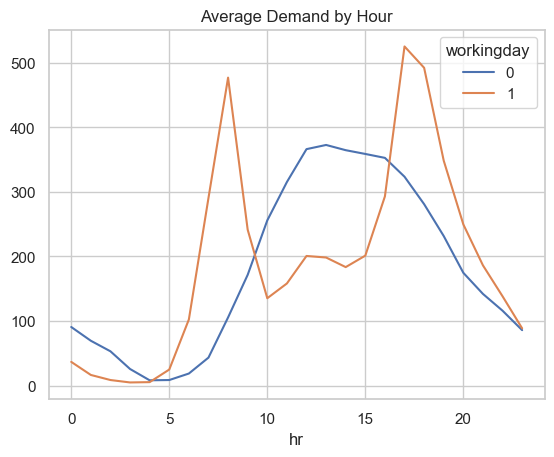

In [19]:
df.groupby(["hr","workingday"])["cnt"].mean().unstack().plot(title="Average Demand by Hour")

Findings: Comparing non-working days (0) and working days (1), I found that on working days demand spikes during peak commuting hoursaround 7–8am and again at 6pm after work reaching close to 500 or more rentals per hour. On non-working days there is instead a single peak around noon, at roughly 360 rentals. What this tells us is that working day demand is driven by commuters with two peak hours, while non-working-day demand follows a leisure pattern with one afternoon peak.

<Axes: title={'center': 'Average Demand by Temperature Bin'}, xlabel='temp'>

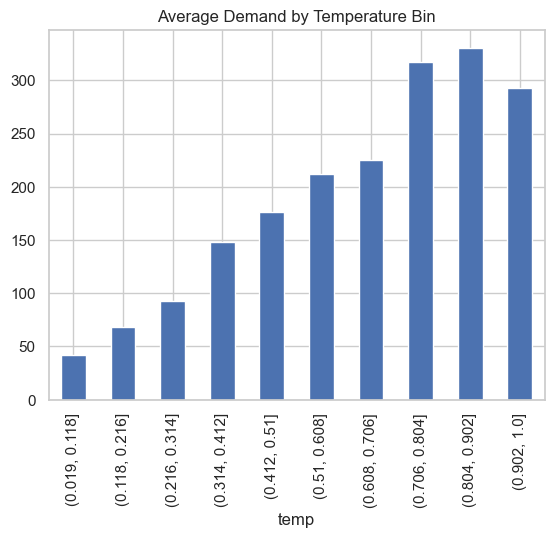

In [20]:
df.groupby(pd.cut(df["temp"], bins=10))["cnt"].mean().plot(
    kind="bar", title="Average Demand by Temperature Bin"
)

Findings: Comparing temperature to bike demand, I found that as the weather gets warmer, riders are more likely to rent a bike:average demand rises steadily across the temperature bins.

<Axes: xlabel='temp', ylabel='cnt'>

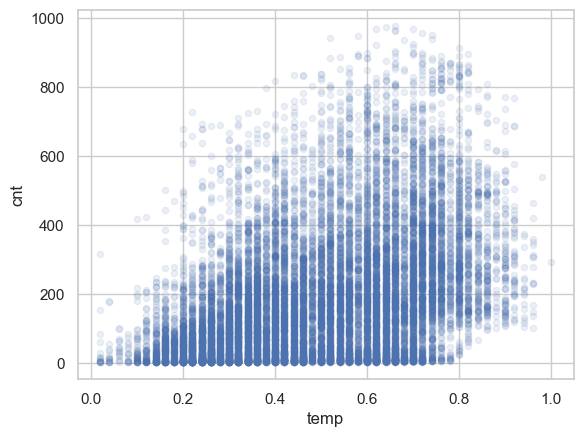

In [21]:
df.plot.scatter(x="temp", y="cnt", alpha=0.1)

Findings: This plot shows an upward trajectory in how temperature affects demand and as temprature passes 32. celcius it biker number begin to flatten out making this a non linear . Note that temperature in this dataset is normalized to a 0–1 scale (multiply by 41 for °C); the densest band of high-demand hours sits in the warm mid-range rather than at the extremes.

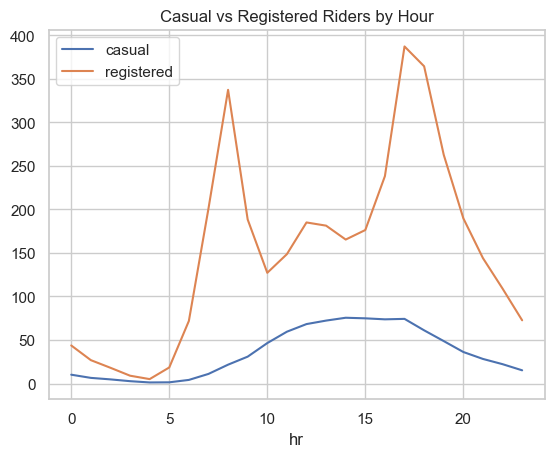

In [22]:
df.groupby("hr")[["casual", "registered"]].mean().plot(
    title="Casual vs Registered Riders by Hour"
)
plt.show()

Findings: This graph compares average casual and registered riders at each hour. Registered riders outnumber casual riders across nearly all hours, and their peaks land at 7–8am and 6pm:  matching the commuter pattern in the working day demand graph earlier. Casual riders behave differently: their usage builds through the afternoon with a single peak around noon, and at a lower volume than the registered peaks. This confirms the two distinct rider populations behind overall demand. (These two columns sum to the target, so they are used for analysis only — not as model features.)

## Part 2 Modeling 

## Time based split 

In [ ]:
# This ensures data is sorted chronologically
df = df.sort_values(["dteday","hr"])

# Determine split index (e.g., 80% train, 20% test)
train_size = int(len(df) * 0.8)

# Split the data
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

features = ["hr", "workingday", "holiday", "season", "weathersit", "temp", "hum", "windspeed"]
target = "cnt"

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

I used a time-based split instead of a random split because this is time series data. A random split would let the model train on hours from the future and be tested on the past, which inflates the score in a way that wouldn't hold up in real use. Sorting chronologically and training on the first 80% of the timeline means the model is always evaluated on a future it never saw.

In [24]:
from sklearn.metrics import root_mean_squared_error

baseline_pred = np.full(len(y_test), y_train.mean())   # an array that's just the mean, repeated
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 232.61


In [25]:
from xgboost import XGBRegressor
model = XGBRegressor(objective="reg:squarederror", n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
model_rmse = root_mean_squared_error(y_test, y_pred)

print(f"XGBoost RMSE:  {model_rmse:.2f}")

XGBoost RMSE:  120.20


The model cuts error roughly in half versus the baseline of 232.61

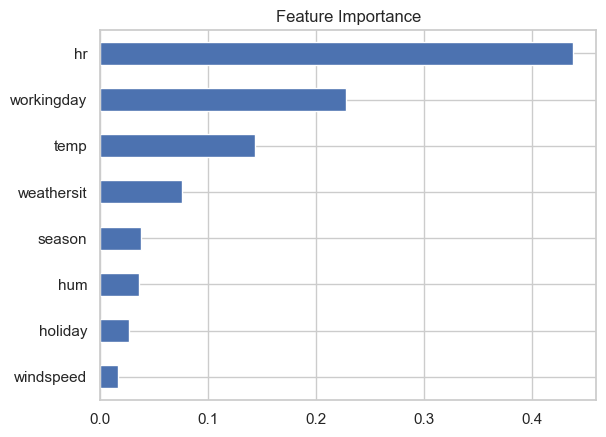

In [26]:
pd.Series(model.feature_importances_, index=features).sort_values().plot(
    kind="barh", title="Feature Importance"
)
plt.show()

This plot depicts the importance of each feature in predicting hourly bike rentals. Hour is the most notable feature, with working day and temperature as the next two: which matches what I initially hypothesized from the exploratory analysis.